## Linear Probes 2

### To Rule or Not To Rule 2: Attn Vs MLP 💪

The linear probes on residual stream clearly showed that the model understands throughout the layers whether it's been given a rule or not. However, Combinatorial Subspace Subtraction binding vectors show that those "binding vectors" are mostly noise.

These linear probes are going to run on MLPs and Attn layers to see which one is more responsible for the rule processing.

### Setup and Imports

In [ ]:
!pip install seaborn plotly transformer_lens
!pip uninstall -y torchaudio

In [ ]:
import json
import numpy as np
import torch
from google.colab import drive
from huggingface_hub import login
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
from transformer_lens import HookedTransformer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import plotly.express as px
from google.colab import files

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!ls drive/MyDrive/Projects/PRISM/data

CombSub_dataset.json		   GrammarDiss_dataset_variantC.json
GrammarDiss_contexts.json	   GrammarDiss_dataset_variantD.json
GrammarDiss_dataset_variantA.json  GrammarDiss_rules.json
GrammarDiss_dataset_variantB.json


In [ ]:
# HF login for Llamas
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained_no_processing(
    "meta-llama/Llama-3.2-1B-Instruct",
    device=device,
    torch_dtype=torch.float16,
)

n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer


In [ ]:
def extract_contrastive_features(samples, component_name="hook_resid_post"):
  """Helper function to extract the activations."""
  contrastive_acts = np.zeros((len(samples), n_layers, d_model), dtype=np.float32)
  labels = np.zeros(len(samples), dtype=np.int32)

  for idx, sample in enumerate(samples):
      ctx_rule_text = sample["assembled_input"]
      ctx_only_text = sample["context"]
      labels[idx] = sample["label"]

      # Inference
      with torch.no_grad():
          _, cache_full = model.run_with_cache(ctx_rule_text, stop_at_layer=n_layers)
          _, cache_ctx = model.run_with_cache(ctx_only_text, stop_at_layer=n_layers)

      # Contrastive vector
      for layer in range(n_layers):
          hook_name = f"blocks.{layer}.{component_name}"

          act_full = cache_full[hook_name][0, -1, :].cpu().numpy()
          act_ctx = cache_ctx[hook_name][0, -1, :].cpu().numpy()

          contrastive_acts[idx, layer, :] = act_full - act_ctx

      del cache_full, cache_ctx
      torch.cuda.empty_cache()

  return contrastive_acts, labels

In [ ]:
def visualize_pca_across_layers(activation_vectors, labels, layer_idx, prefix, dataset_suffix="A"):
  """Generates and downloads 3D PCA visualizations for MLP activation vectors across all layers."""
  layer_data = activation_vectors[:, layer_idx, :]
  rule_labels = labels

  pca = PCA(n_components=3)
  pca_results = pca.fit_transform(layer_data)

  fig = px.scatter_3d(
      x=pca_results[:, 0],
      y=pca_results[:, 1],
      z=pca_results[:, 2],
      color=rule_labels,
      labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
      title=f"3D PCA Manifold of MLP Activation Vectors (Layer {layer_idx}) - Dataset A Train",
      opacity=0.8,
      color_discrete_sequence=px.colors.qualitative.Bold
  )

  fig.update_layout(
      margin=dict(l=0, r=0, b=0, t=40),
      scene=dict(
          xaxis=dict(backgroundcolor="rgba(0,0,0,0)"),
          yaxis=dict(backgroundcolor="rgba(0,0,0,0)"),
          zaxis=dict(backgroundcolor="rgba(0,0,0,0)")
      )
  )

  filename = f"{prefix}_pca_3d_layer{layer_idx}_dataset{dataset_suffix}_train.html"
  fig.write_html(filename)
  files.download(filename)

### Dataset A

In [ ]:
FILE_PATH_A = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantA.json"

In [ ]:
with open(FILE_PATH_A, "r", encoding="utf-8") as f:
    datasetA = json.load(f)

In [ ]:
train_listA = datasetA["train"]
test_listA = datasetA["test"]

#### Dataset A - Attention Output Probes

In [ ]:
X_train_all_A, y_train_A = extract_contrastive_features(train_listA, component_name="hook_attn_out")
X_test_all_A, y_test_A = extract_contrastive_features(test_listA, component_name="hook_attn_out")

NameError: name 'n_layers' is not defined

In [ ]:
layer_accs = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_A = X_train_all_A[:, layer, :]
    X_test_layer_A = X_test_all_A[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_A, y_train_A)

    train_acc = accuracy_score(y_train_A, probe.predict(X_train_layer_A))
    test_preds_A = probe.predict(X_test_layer_A)
    test_acc = accuracy_score(y_test_A, test_preds_A)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_A,
            test_preds_A,
            target_names=["No Grammar (0)", "Imperative (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accs.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

NameError: name 'n_layers' is not defined

#### Dataset A - MLP Output Probes

In [ ]:
MLPX_train_all_A, MLPy_train_A = extract_contrastive_features(train_listA, component_name="hook_mlp_out")
MLPX_test_all_A, MLPy_test_A = extract_contrastive_features(test_listA, component_name="hook_mlp_out")

NameError: name 'n_layers' is not defined

In [ ]:
MLPlayer_accs = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_A = MLPX_train_all_A[:, layer, :]
    MLPX_test_layer_A = MLPX_test_all_A[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_A, MLPy_train_A)

    train_acc = accuracy_score(MLPy_train_A, probe.predict(MLPX_train_layer_A))
    MLPtest_preds_A = probe.predict(MLPX_test_layer_A)
    test_acc = accuracy_score(MLPy_test_A, MLPtest_preds_A)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_A,
            MLPtest_preds_A,
            target_names=["No Grammar (0)", "Imperative (1)"],
            zero_division=0
        )
    )
    print('################################################')
    MLPlayer_accs.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

NameError: name 'n_layers' is not defined

### Dataset B

In [ ]:
FILE_PATH_B = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantB.json"

In [ ]:
with open(FILE_PATH_B, "r", encoding="utf-8") as f:
    datasetB = json.load(f)

In [ ]:
train_listB = datasetB["train"]
test_listB = datasetB["test"]

#### Dataset B - Attention Output Probes

In [ ]:
X_train_all_B, y_train_B = extract_contrastive_features(train_listB, component_name="hook_attn_out")
X_test_all_B, y_test_B = extract_contrastive_features(test_listB, component_name="hook_attn_out")

NameError: name 'n_layers' is not defined

In [ ]:
layer_accsB = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_B = X_train_all_B[:, layer, :]
    X_test_layer_B = X_test_all_B[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_B, y_train_B)

    train_acc = accuracy_score(y_train_B, probe.predict(X_train_layer_B))
    test_preds_B = probe.predict(X_test_layer_B)
    test_acc = accuracy_score(y_test_B, test_preds_B)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_B,
            test_preds_B,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accsB.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

NameError: name 'X_train_all_B' is not defined

#### Dataset B - MLP Output Probes

In [ ]:
MLPX_train_all_B, MLPy_train_B = extract_contrastive_features(train_listB, component_name="hook_mlp_out")
MLPX_test_all_B, MLPy_test_B = extract_contrastive_features(test_listB, component_name="hook_mlp_out")

KeyboardInterrupt: 

In [ ]:
MLPlayer_accsB = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_B = MLPX_train_all_B[:, layer, :]
    MLPX_test_layer_B = MLPX_test_all_B[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_B, MLPy_train_B)

    train_acc = accuracy_score(MLPy_train_B, probe.predict(MLPX_train_layer_B))
    MLPtest_preds_B = probe.predict(MLPX_test_layer_B)
    test_acc = accuracy_score(MLPy_test_B, MLPtest_preds_B)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_B,
            MLPtest_preds_B,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    MLPlayer_accsB.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

### Dataset C

The previous rules from both data subsets were very language-heavy. So I wondered if it put "extra pressure" on the latest layer, since the model had to pick the right language to answer and then generate in it.

To make sure, this subset does not have lang-related rules at all.

In [ ]:
FILE_PATH_C = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantC.json"

In [ ]:
with open(FILE_PATH_C, "r", encoding="utf-8") as f:
    datasetC = json.load(f)

In [ ]:
train_listC = datasetC["train"]
test_listC = datasetC["test"]

#### Dataset C - Attention Output Probes

In [ ]:
X_train_all_C, y_train_C = extract_contrastive_features(train_listC, component_name="hook_attn_out")
X_test_all_C, y_test_C = extract_contrastive_features(test_listC, component_name="hook_attn_out")

In [ ]:
layer_accsC = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_C = X_train_all_C[:, layer, :]
    X_test_layer_C = X_test_all_C[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_C, y_train_C)

    train_acc = accuracy_score(y_train_C, probe.predict(X_train_layer_C))
    test_preds_C = probe.predict(X_test_layer_C)
    test_acc = accuracy_score(y_test_C, test_preds_C)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_C,
            test_preds_C,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accsC.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

#### Dataset C - MLP Output Probes

In [ ]:
MLPX_train_all_C, MLPy_train_C = extract_contrastive_features(train_listC, component_name="hook_mlp_out")
MLPX_test_all_C, MLPy_test_C = extract_contrastive_features(test_listC, component_name="hook_mlp_out")

In [ ]:
MLPlayer_accsC = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_C = MLPX_train_all_C[:, layer, :]
    MLPX_test_layer_C = MLPX_test_all_C[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_C, MLPy_train_C)

    train_acc = accuracy_score(MLPy_train_C, probe.predict(MLPX_train_layer_C))
    MLPtest_preds_C = probe.predict(MLPX_test_layer_C)
    test_acc = accuracy_score(MLPy_test_C, MLPtest_preds_C)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_C,
            MLPtest_preds_C,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    MLPlayer_accsC.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

### Dataset D

In [ ]:
FILE_PATH_D = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantD.json"

In [ ]:
with open(FILE_PATH_D, "r", encoding="utf-8") as f:
    datasetD = json.load(f)

In [ ]:
train_listD = datasetD["train"]
test_listD = datasetD["test"]

#### Dataset D - Attention Output Probes

In [ ]:
X_train_all_D_attn, y_train_D_attn = extract_contrastive_features(train_listD, component_name="hook_attn_out")
X_test_all_D_attn, y_test_D_attn = extract_contrastive_features(test_listD, component_name="hook_attn_out")

In [ ]:
attn_layer_accsD = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_D_attn = X_train_all_D_attn[:, layer, :]
    X_test_layer_D_attn = X_test_all_D_attn[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_D_attn, y_train_D_attn)

    train_acc = accuracy_score(y_train_D_attn, probe.predict(X_train_layer_D_attn))
    test_preds_D_attn = probe.predict(X_test_layer_D_attn)
    test_acc = accuracy_score(y_test_D_attn, test_preds_D_attn)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_D_attn,
            test_preds_D_attn,
            target_names=["no_grammar (0)", "declarative_past (1)"],
            zero_division=0
        )
    )
    print('################################################')
    attn_layer_accsD.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.99, Test: 0.9800                
                      precision    recall  f1-score   support

      no_grammar (0)       1.00      0.96      0.98        50
declarative_past (1)       0.96      1.00      0.98        50

            accuracy                           0.98       100
           macro avg       0.98      0.98      0.98       100
        weighted avg       0.98      0.98      0.98       100

################################################
1
Train: 0.995, Test: 0.9900                
                      precision    recall  f1-score   support

      no_grammar (0)       1.00      0.98      0.99        50
declarative_past (1)       0.98      1.00      0.99        50

            accuracy                           0.99       100
           macro avg       0.99      0.99      0.99       100
        weighted avg       0.99      0.99      0.99       100

################################################
2
Train: 1.0, Test: 1.0000                
                    

#### Dataset D - MLP Output Probes

In [ ]:
MLPX_train_all_D, MLPy_train_D = extract_contrastive_features(train_listD, component_name="hook_mlp_out")
MLPX_test_all_D, MLPy_test_D = extract_contrastive_features(test_listD, component_name="hook_mlp_out")

In [ ]:
mlp_layer_accsD = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_D = MLPX_train_all_D[:, layer, :]
    MLPX_test_layer_D = MLPX_test_all_D[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_D, MLPy_train_D)

    train_acc = accuracy_score(MLPy_train_D, probe.predict(MLPX_train_layer_D))
    MLPtest_preds_D = probe.predict(MLPX_test_layer_D)
    test_acc = accuracy_score(MLPy_test_D, MLPtest_preds_D)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_D,
            MLPtest_preds_D,
            target_names=["no_grammar (0)", "declarative_past (1)"],
            zero_division=0
        )
    )
    print('################################################')
    mlp_layer_accsD.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.995, Test: 0.9800                
                      precision    recall  f1-score   support

      no_grammar (0)       1.00      0.96      0.98        50
declarative_past (1)       0.96      1.00      0.98        50

            accuracy                           0.98       100
           macro avg       0.98      0.98      0.98       100
        weighted avg       0.98      0.98      0.98       100

################################################
1
Train: 0.995, Test: 0.9900                
                      precision    recall  f1-score   support

      no_grammar (0)       1.00      0.98      0.99        50
declarative_past (1)       0.98      1.00      0.99        50

            accuracy                           0.99       100
           macro avg       0.99      0.99      0.99       100
        weighted avg       0.99      0.99      0.99       100

################################################
2
Train: 1.0, Test: 1.0000                
                   

#### Dataset D - Residual Stream Probes

In [ ]:
ResidX_train_all_D, ResidY_train_D = extract_contrastive_features(train_listD, component_name="hook_resid_post")
ResidX_test_all_D, ResidY_test_D = extract_contrastive_features(test_listD, component_name="hook_resid_post")

In [ ]:
resid_layer_accsD = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    ResidX_train_layer_D = ResidX_train_all_D[:, layer, :]
    ResidX_test_layer_D = ResidX_test_all_D[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(ResidX_train_layer_D, ResidY_train_D)

    train_acc = accuracy_score(ResidY_train_D, probe.predict(ResidX_train_layer_D))
    Residtest_preds_D = probe.predict(ResidX_test_layer_D)
    test_acc = accuracy_score(ResidY_test_D, Residtest_preds_D)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            ResidY_test_D,
            Residtest_preds_D,
            target_names=["no_grammar (0)", "declarative_past (1)"],
            zero_division=0
        )
    )
    print('################################################')
    resid_layer_accsD.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.995, Test: 0.9900                
                      precision    recall  f1-score   support

      no_grammar (0)       1.00      0.98      0.99        50
declarative_past (1)       0.98      1.00      0.99        50

            accuracy                           0.99       100
           macro avg       0.99      0.99      0.99       100
        weighted avg       0.99      0.99      0.99       100

################################################
1
Train: 1.0, Test: 1.0000                
                      precision    recall  f1-score   support

      no_grammar (0)       1.00      1.00      1.00        50
declarative_past (1)       1.00      1.00      1.00        50

            accuracy                           1.00       100
           macro avg       1.00      1.00      1.00       100
        weighted avg       1.00      1.00      1.00       100

################################################
2
Train: 1.0, Test: 1.0000                
                     

### Visualizations

ValueError: x and y must have same first dimension, but have shapes (16,) and (0,)

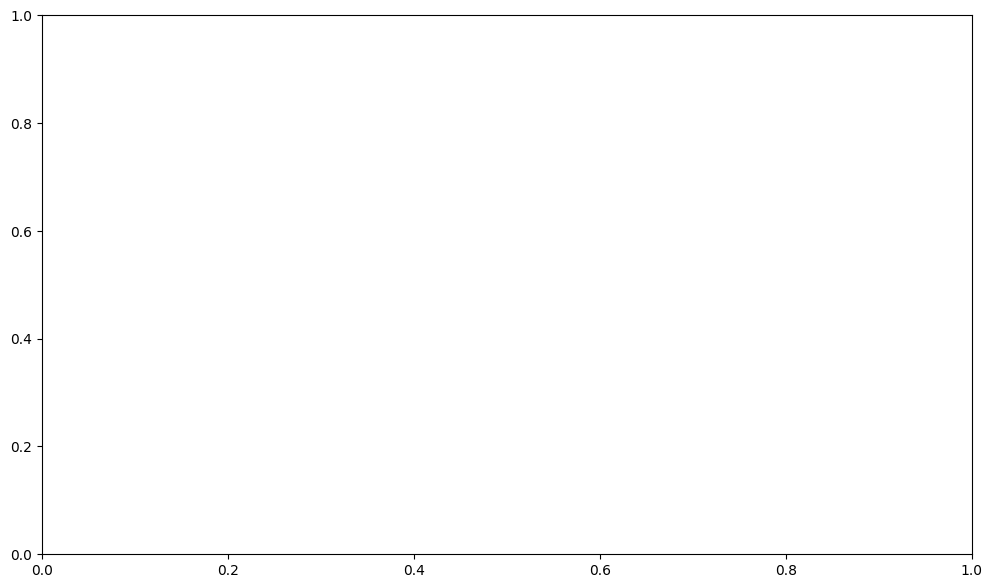

In [ ]:
import matplotlib.pyplot as plt

# Extract test accuracies for attention probes
attn_test_accs_A = [d['test_acc'] for d in layer_accs]

# Extract test accuracies for MLP probes
mlp_test_accs_A = [d['test_acc'] for d in MLPlayer_accs]

layers = range(n_layers)

plt.figure(figsize=(12, 7))

# Plot Attention Probes
plt.plot(layers, attn_test_accs_A, linestyle='-', marker='o', color='forestgreen', label='Dataset A (Attn)')

# Plot MLP Probes
plt.plot(layers, mlp_test_accs_A, linestyle='--', marker='D', color='darkblue', label='Dataset A (MLP)')

plt.xlabel('Layer')
plt.ylabel('Test Accuracy')
plt.title('Layer-wise Test Accuracy for Attn and MLP Probes (Dataset A)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

#### PCA Visualizations - Dataset A

In [ ]:
# MLPs A - Layer 4
visualize_pca_across_layers(MLPX_train_all_A, MLPy_train_A, 4, 'MLPs_A', 'A')

In [ ]:
# MLPs A - Layer 15
visualize_pca_across_layers(MLPX_train_all_A, MLPy_train_A, 15, 'MLPs_A', 'A')

#### PCA Visualizations - Dataset B

In [ ]:
# MLPs B - Layer 4
visualize_pca_across_layers(MLPX_train_all_B, MLPy_train_B, 4, 'MLPs_B', 'B')

In [ ]:
# MLPs B - Layer 15
visualize_pca_across_layers(MLPX_train_all_B, MLPy_train_B, 15, 'MLPs_B', 'B')

#### PCA Visualizations - Dataset C

In [ ]:
# MLPs C - Layer 4
visualize_pca_across_layers(MLPX_train_all_C, MLPy_train_C, 4, 'MLPs_C', 'C')

In [ ]:
# MLPs C - Layer 15
visualize_pca_across_layers(MLPX_train_all_C, MLPy_train_C, 15, 'MLPs_C', 'C')

#### PCA Visualizations - Dataset D

In [ ]:
# MLPs D - Layer 4
visualize_pca_across_layers(MLPX_train_all_D, MLPy_train_D, 4, 'MLPs_D', 'D')

In [ ]:
# MLPs D - Layer 15
visualize_pca_across_layers(MLPX_train_all_D, MLPy_train_D, 15, 'MLPs_D', 'D')

## Linear Probes 2

### To Rule or Not To Rule 2: Attn Vs MLP 💪

The linear probes on residual stream clearly showed that the model understands throughout the layers whether it's been given a rule or not. However, Combinatorial Subspace Subtraction binding vectors show that those "binding vectors" are mostly noise.

These linear probes are going to run on MLPs and Attn layers to see which one is more responsible for the rule processing.

In [ ]:
!pip install seaborn plotly transformer_lens
!pip uninstall -y torchaudio

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import json
import numpy as np
import torch
from google.colab import drive
from huggingface_hub import login
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
from transformer_lens import HookedTransformer

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!ls drive/MyDrive/Projects/PRISM/data

CombSub_dataset.json		   GrammarDiss_dataset_variantB.json
GrammarDiss_contexts.json	   GrammarDiss_dataset_variantC.json
GrammarDiss_dataset_variantA.json  GrammarDiss_rules.json


### Setup

In [ ]:
# HF login for Llamas
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained_no_processing(
    "meta-llama/Llama-3.2-1B-Instruct",
    device=device,
    torch_dtype=torch.float16,
)

n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer


In [ ]:
FILE_PATH_A = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantA.json"
FILE_PATH_B = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantB.json"

In [ ]:
with open(FILE_PATH_A, "r", encoding="utf-8") as f:
    datasetA = json.load(f)

with open(FILE_PATH_B, "r", encoding="utf-8") as f:
    datasetB = json.load(f)

In [ ]:
train_listA = datasetA["train"]
test_listA = datasetA["test"]

train_listB = datasetB["train"]
test_listB = datasetB["test"]

In [ ]:
def extract_contrastive_features(samples, component_name="hook_resid_post"):
  """Helper function to extract the activations."""
  contrastive_acts = np.zeros((len(samples), n_layers, d_model), dtype=np.float32)
  labels = np.zeros(len(samples), dtype=np.int32)

  for idx, sample in enumerate(samples):
      ctx_rule_text = sample["assembled_input"]
      ctx_only_text = sample["context"]
      labels[idx] = sample["label"]

      # Inference
      with torch.no_grad():
          _, cache_full = model.run_with_cache(ctx_rule_text, stop_at_layer=n_layers)
          _, cache_ctx = model.run_with_cache(ctx_only_text, stop_at_layer=n_layers)

      # Contrastive vector
      for layer in range(n_layers):
          hook_name = f"blocks.{layer}.{component_name}"

          act_full = cache_full[hook_name][0, -1, :].cpu().numpy()
          act_ctx = cache_ctx[hook_name][0, -1, :].cpu().numpy()

          contrastive_acts[idx, layer, :] = act_full - act_ctx

      del cache_full, cache_ctx
      torch.cuda.empty_cache()

  return contrastive_acts, labels

## Attention First

In [ ]:
X_train_all_A, y_train_A = extract_contrastive_features(train_listA, component_name="hook_attn_out")
X_test_all_A, y_test_A = extract_contrastive_features(test_listA, component_name="hook_attn_out")

In [ ]:
X_train_all_B, y_train_B = extract_contrastive_features(train_listB, component_name="hook_attn_out")
X_test_all_B, y_test_B = extract_contrastive_features(test_listB, component_name="hook_attn_out")

In [ ]:
X_train_all_A.shape, X_train_all_B.shape

((200, 16, 2048), (200, 16, 2048))

In [ ]:
layer_accs = []
layer_accsB = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_A = X_train_all_A[:, layer, :]
    X_test_layer_A = X_test_all_A[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_A, y_train_A)

    train_acc = accuracy_score(y_train_A, probe.predict(X_train_layer_A))
    test_preds_A = probe.predict(X_test_layer_A)
    test_acc = accuracy_score(y_test_A, test_preds_A)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_A,
            test_preds_A,
            target_names=["No Grammar (0)", "Imperative (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accs.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.985, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00      0.00        50
Imperative (1)       0.50      1.00      0.67        50

      accuracy                           0.50       100
     macro avg       0.25      0.50      0.33       100
  weighted avg       0.25      0.50      0.33       100

################################################
1
Train: 0.995, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00      0.00        50
Imperative (1)       0.50      1.00      0.67        50

      accuracy                           0.50       100
     macro avg       0.25      0.50      0.33       100
  weighted avg       0.25      0.50      0.33       100

################################################
2
Train: 1.0, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.0

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_B = X_train_all_B[:, layer, :]
    X_test_layer_B = X_test_all_B[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_B, y_train_B)

    train_acc = accuracy_score(y_train_B, probe.predict(X_train_layer_B))
    test_preds_B = probe.predict(X_test_layer_B)
    test_acc = accuracy_score(y_test_B, test_preds_B)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_B,
            test_preds_B,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accsB.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.99, Test: 0.5300                
                      precision    recall  f1-score   support

Declarative Past (0)       0.58      0.22      0.32        50
Modal Obligation (1)       0.52      0.84      0.64        50

            accuracy                           0.53       100
           macro avg       0.55      0.53      0.48       100
        weighted avg       0.55      0.53      0.48       100

################################################
1
Train: 1.0, Test: 0.9300                
                      precision    recall  f1-score   support

Declarative Past (0)       0.98      0.88      0.93        50
Modal Obligation (1)       0.89      0.98      0.93        50

            accuracy                           0.93       100
           macro avg       0.93      0.93      0.93       100
        weighted avg       0.93      0.93      0.93       100

################################################
2
Train: 0.995, Test: 0.6900                
                    

In [ ]:
FILE_PATH_C = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantC.json"

In [ ]:
FILE_PATH_D = "/content/drive/MyDrive/Projects/PRISM/data/GrammarDiss_dataset_variantD.json"

In [ ]:
with open(FILE_PATH_D, "r", encoding="utf-8") as f:
    datasetD = json.load(f)

In [ ]:
train_listD = datasetD["train"]
test_listD = datasetD["test"]

## Dataset D - Attention Output Probes

In [ ]:
X_train_all_D_attn, y_train_D_attn = extract_contrastive_features(train_listD, component_name="hook_attn_out")
X_test_all_D_attn, y_test_D_attn = extract_contrastive_features(test_listD, component_name="hook_attn_out")

In [ ]:
attn_layer_accsD = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_D_attn = X_train_all_D_attn[:, layer, :]
    X_test_layer_D_attn = X_test_all_D_attn[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_D_attn, y_train_D_attn)

    train_acc = accuracy_score(y_train_D_attn, probe.predict(X_train_layer_D_attn))
    test_preds_D_attn = probe.predict(X_test_layer_D_attn)
    test_acc = accuracy_score(y_test_D_attn, test_preds_D_attn)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_D_attn,
            test_preds_D_attn,
            target_names=["no_grammar (0)", "declarative_past (1)"],
            zero_division=0
        )
    )
    print('################################################')
    attn_layer_accsD.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

## Dataset D - MLP Output Probes

In [ ]:
MLPX_train_all_D, MLPy_train_D = extract_contrastive_features(train_listD, component_name="hook_mlp_out")
MLPX_test_all_D, MLPy_test_D = extract_contrastive_features(test_listD, component_name="hook_mlp_out")

In [ ]:
mlp_layer_accsD = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_D = MLPX_train_all_D[:, layer, :]
    MLPX_test_layer_D = MLPX_test_all_D[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_D, MLPy_train_D)

    train_acc = accuracy_score(MLPy_train_D, probe.predict(MLPX_train_layer_D))
    MLPtest_preds_D = probe.predict(MLPX_test_layer_D)
    test_acc = accuracy_score(MLPy_test_D, MLPtest_preds_D)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_D,
            MLPtest_preds_D,
            target_names=["no_grammar (0)", "declarative_past (1)"],
            zero_division=0
        )
    )
    print('################################################')
    mlp_layer_accsD.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

## Dataset D - Residual Stream Probes

In [ ]:
ResidX_train_all_D, ResidY_train_D = extract_contrastive_features(train_listD, component_name="hook_resid_post")
ResidX_test_all_D, ResidY_test_D = extract_contrastive_features(test_listD, component_name="hook_resid_post")

In [ ]:
resid_layer_accsD = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    ResidX_train_layer_D = ResidX_train_all_D[:, layer, :]
    ResidX_test_layer_D = ResidX_test_all_D[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(ResidX_train_layer_D, ResidY_train_D)

    train_acc = accuracy_score(ResidY_train_D, probe.predict(ResidX_train_layer_D))
    Residtest_preds_D = probe.predict(ResidX_test_layer_D)
    test_acc = accuracy_score(ResidY_test_D, Residtest_preds_D)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            ResidY_test_D,
            Residtest_preds_D,
            target_names=["no_grammar (0)", "declarative_past (1)"],
            zero_division=0
        )
    )
    print('################################################')
    resid_layer_accsD.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

## Combined Accuracy Plot for All Datasets and Components

In [ ]:
import matplotlib.pyplot as plt

# Extract test accuracies for attention probes
attn_test_accs_A = [d['test_acc'] for d in layer_accs]
attn_test_accs_B = [d['test_acc'] for d in layer_accsB]
attn_test_accs_C = [d['test_acc'] for d in layer_accsC]
attn_test_accs_D = [d['test_acc'] for d in attn_layer_accsD]

# Extract test accuracies for MLP probes
mlp_test_accs_A = [d['test_acc'] for d in MLPlayer_accs]
mlp_test_accs_B = [d['test_acc'] for d in MLPlayer_accsB]
mlp_test_accs_C = [d['test_acc'] for d in MLPlayer_accsC]
mlp_test_accs_D = [d['test_acc'] for d in mlp_layer_accsD]

# Extract test accuracies for Residual Stream probes (only for D currently, assuming others were not run for resid_post)
resid_test_accs_D = [d['test_acc'] for d in resid_layer_accsD]

layers = range(n_layers)

plt.figure(figsize=(15, 9))

# Plot Attention Probes
plt.plot(layers, attn_test_accs_A, linestyle='-', marker='o', color='forestgreen', label='Dataset A (Attn)')
plt.plot(layers, attn_test_accs_B, linestyle='-', marker='o', color='lightgreen', label='Dataset B (Attn)')
plt.plot(layers, attn_test_accs_C, linestyle='-', marker='o', color='darkcyan', label='Dataset C (Attn)')
plt.plot(layers, attn_test_accs_D, linestyle='-', marker='o', color='mediumaquamarine', label='Dataset D (Attn)')

# Plot MLP Probes
plt.plot(layers, mlp_test_accs_A, linestyle='--', marker='D', color='darkblue', label='Dataset A (MLP)')
plt.plot(layers, mlp_test_accs_B, linestyle='--', marker='D', color='skyblue', label='Dataset B (MLP)')
plt.plot(layers, mlp_test_accs_C, linestyle='--', marker='D', color='indigo', label='Dataset C (MLP)')
plt.plot(layers, mlp_test_accs_D, linestyle='--', marker='D', color='cornflowerblue', label='Dataset D (MLP)')

# Plot Residual Stream Probes
plt.plot(layers, resid_test_accs_D, linestyle=':', marker='X', color='red', label='Dataset D (Resid)')

plt.xlabel('Layer')
plt.ylabel('Test Accuracy')
plt.title('Layer-wise Test Accuracy for Attn, MLP, and Residual Probes (All Datasets)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside for clarity
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(-0.05, 1.05) # Set y-axis limits to clearly show 0 to 1 accuracy
plt.tight_layout()
plt.show()

## PCA Visualization for Dataset D (MLP Output)

In [ ]:
# MLPs D - Layer 4
visualize_pca_across_layers(MLPX_train_all_D, MLPy_train_D, 4, 'MLPs_D', 'D')

In [ ]:
# MLPs D - Layer 15
visualize_pca_across_layers(MLPX_train_all_D, MLPy_train_D, 15, 'MLPs_D', 'D')

In [ ]:
with open(FILE_PATH_C, "r", encoding="utf-8") as f:
    datasetC = json.load(f)

In [ ]:
train_listC = datasetC["train"]
test_listC = datasetC["test"]

In [ ]:
X_train_all_C, y_train_C = extract_contrastive_features(train_listC, component_name="hook_attn_out")
X_test_all_C, y_test_C = extract_contrastive_features(test_listC, component_name="hook_attn_out")

In [ ]:
layer_accsC = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    X_train_layer_C = X_train_all_C[:, layer, :]
    X_test_layer_C = X_test_all_C[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_C, y_train_C)

    train_acc = accuracy_score(y_train_C, probe.predict(X_train_layer_C))
    test_preds_C = probe.predict(X_test_layer_C)
    test_acc = accuracy_score(y_test_C, test_preds_C)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            y_test_C,
            test_preds_C,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    layer_accsC.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.985, Test: 0.9900                
                      precision    recall  f1-score   support

Declarative Past (0)       1.00      0.98      0.99        50
Modal Obligation (1)       0.98      1.00      0.99        50

            accuracy                           0.99       100
           macro avg       0.99      0.99      0.99       100
        weighted avg       0.99      0.99      0.99       100

################################################
1
Train: 1.0, Test: 1.0000                
                      precision    recall  f1-score   support

Declarative Past (0)       1.00      1.00      1.00        50
Modal Obligation (1)       1.00      1.00      1.00        50

            accuracy                           1.00       100
           macro avg       1.00      1.00      1.00       100
        weighted avg       1.00      1.00      1.00       100

################################################
2
Train: 1.0, Test: 1.0000                
                     

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

recall_label0_A = []
recall_label1_A = []

# Recalculate per-label accuracy for Dataset A
for layer in range(n_layers):
    X_train_layer_A = X_train_all_A[:, layer, :]
    X_test_layer_A = X_test_all_A[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_A, y_train_A)

    test_preds_A = probe.predict(X_test_layer_A)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(y_test_A, test_preds_A, average=None, zero_division=0)

    recall_label0_A.append(metrics[1][0]) # Recall for label 0
    recall_label1_A.append(metrics[1][1]) # Recall for label 1

recall_label0_B = []
recall_label1_B = []

# Recalculate per-label accuracy for Dataset B
for layer in range(n_layers):
    X_train_layer_B = X_train_all_B[:, layer, :]
    X_test_layer_B = X_test_all_B[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_B, y_train_B)

    test_preds_B = probe.predict(X_test_layer_B)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(y_test_B, test_preds_B, average=None, zero_division=0)

    recall_label0_B.append(metrics[1][0]) # Recall for label 0
    recall_label1_B.append(metrics[1][1]) # Recall for label 1

recall_label0_C = []
recall_label1_C = []

# Recalculate per-label accuracy for Dataset B
for layer in range(n_layers):
    X_train_layer_C = X_train_all_C[:, layer, :]
    X_test_layer_C = X_test_all_C[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train_layer_C, y_train_C)

    test_preds_C = probe.predict(X_test_layer_C)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(y_test_C, test_preds_C, average=None, zero_division=0)

    recall_label0_C.append(metrics[1][0]) # Recall for label 0
    recall_label1_C.append(metrics[1][1]) # Recall for label 1


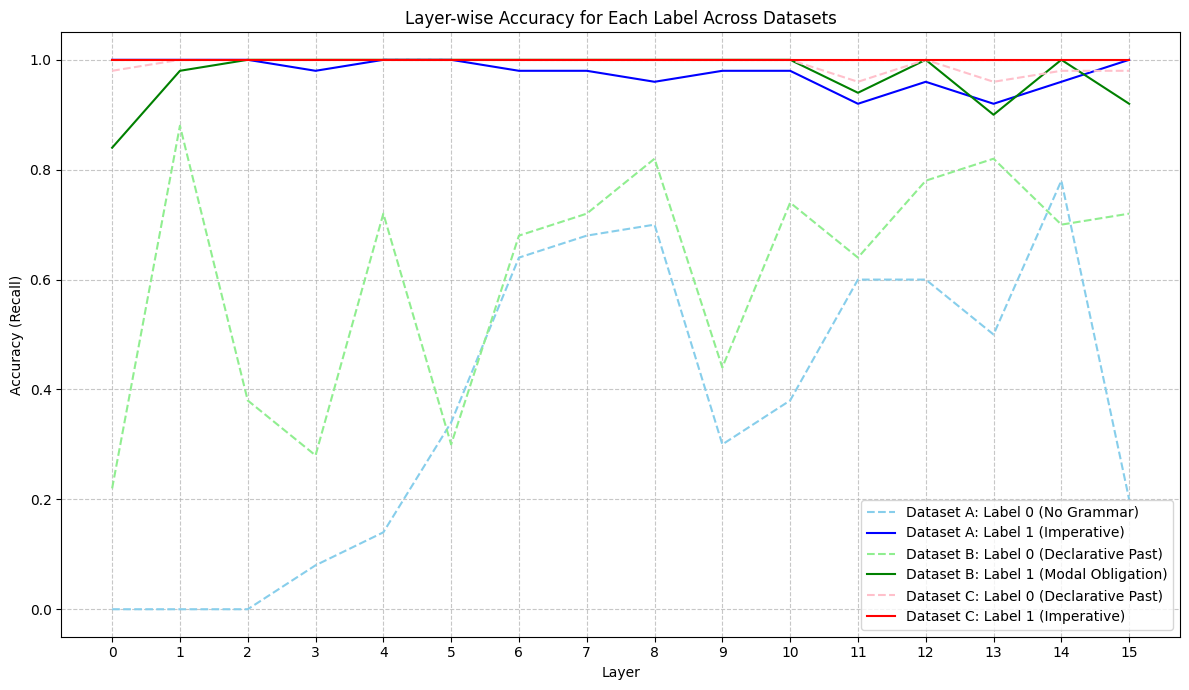

In [ ]:
layers = range(n_layers)

plt.figure(figsize=(12, 7))

# Plot Dataset A
plt.plot(layers, recall_label0_A, linestyle='--', color='skyblue', label='Dataset A: Label 0 (No Grammar)')
plt.plot(layers, recall_label1_A, linestyle='-', color='blue', label='Dataset A: Label 1 (Imperative)')

# Plot Dataset B
plt.plot(layers, recall_label0_B, linestyle='--', color='lightgreen', label='Dataset B: Label 0 (Declarative Past)')
plt.plot(layers, recall_label1_B, linestyle='-', color='green', label='Dataset B: Label 1 (Modal Obligation)')

# Plot Dataset C
plt.plot(layers, recall_label0_C, linestyle='--', color='pink', label='Dataset C: Label 0 (Declarative Past)')
plt.plot(layers, recall_label1_C, linestyle='-', color='red', label='Dataset C: Label 1 (Imperative)')

plt.xlabel('Layer')
plt.ylabel('Accuracy (Recall)')
plt.title('Layer-wise Accuracy for Each Label Across Datasets')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(-0.05, 1.05) # Set y-axis limits to clearly show 0 to 1 accuracy
plt.tight_layout()
plt.show()

## Same for MLPs

In [ ]:
MLPX_train_all_A, MLPy_train_A = extract_contrastive_features(train_listA, component_name="hook_mlp_out")
MLPX_test_all_A, MLPy_test_A = extract_contrastive_features(test_listA, component_name="hook_mlp_out")

In [ ]:
MLPX_train_all_B, MLPy_train_B = extract_contrastive_features(train_listB, component_name="hook_mlp_out")
MLPX_test_all_B, MLPy_test_B = extract_contrastive_features(test_listB, component_name="hook_mlp_out")

In [ ]:
MLPX_train_all_A.shape, MLPX_train_all_B.shape

((200, 16, 2048), (200, 16, 2048))

In [ ]:
MLPlayer_accs = []
MLPlayer_accsB = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_A = MLPX_train_all_A[:, layer, :]
    MLPX_test_layer_A = MLPX_test_all_A[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_A, MLPy_train_A)

    train_acc = accuracy_score(MLPy_train_A, probe.predict(MLPX_train_layer_A))
    MLPtest_preds_A = probe.predict(MLPX_test_layer_A)
    test_acc = accuracy_score(MLPy_test_A, MLPtest_preds_A)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_A,
            MLPtest_preds_A,
            target_names=["No Grammar (0)", "Imperative (1)"],
            zero_division=0
        )
    )
    print('################################################')
    MLPlayer_accs.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.985, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00      0.00        50
Imperative (1)       0.50      1.00      0.67        50

      accuracy                           0.50       100
     macro avg       0.25      0.50      0.33       100
  weighted avg       0.25      0.50      0.33       100

################################################
1
Train: 0.99, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00      0.00        50
Imperative (1)       0.50      1.00      0.67        50

      accuracy                           0.50       100
     macro avg       0.25      0.50      0.33       100
  weighted avg       0.25      0.50      0.33       100

################################################
2
Train: 1.0, Test: 0.5000                
                precision    recall  f1-score   support

No Grammar (0)       0.00      0.00

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_B = MLPX_train_all_B[:, layer, :]
    MLPX_test_layer_B = MLPX_test_all_B[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_B, MLPy_train_B)

    train_acc = accuracy_score(MLPy_train_B, probe.predict(MLPX_train_layer_B))
    MLPtest_preds_B = probe.predict(MLPX_test_layer_B)
    test_acc = accuracy_score(MLPy_test_B, MLPtest_preds_B)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_B,
            MLPtest_preds_B,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    MLPlayer_accsB.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.985, Test: 0.4400                
                      precision    recall  f1-score   support

Declarative Past (0)       0.00      0.00      0.00        50
Modal Obligation (1)       0.47      0.88      0.61        50

            accuracy                           0.44       100
           macro avg       0.23      0.44      0.31       100
        weighted avg       0.23      0.44      0.31       100

################################################
1
Train: 1.0, Test: 0.5400                
                      precision    recall  f1-score   support

Declarative Past (0)       0.75      0.12      0.21        50
Modal Obligation (1)       0.52      0.96      0.68        50

            accuracy                           0.54       100
           macro avg       0.64      0.54      0.44       100
        weighted avg       0.64      0.54      0.44       100

################################################
2
Train: 1.0, Test: 0.7600                
                     

In [ ]:
MLPX_train_all_C, MLPy_train_C = extract_contrastive_features(train_listC, component_name="hook_mlp_out")
MLPX_test_all_C, MLPy_test_C = extract_contrastive_features(test_listC, component_name="hook_mlp_out")

In [ ]:
MLPlayer_accsC = []

In [ ]:
for layer in range(n_layers):
    # extract the layer slice
    MLPX_train_layer_C = MLPX_train_all_C[:, layer, :]
    MLPX_test_layer_C = MLPX_test_all_C[:, layer, :]

    # training
    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_C, MLPy_train_C)

    train_acc = accuracy_score(MLPy_train_C, probe.predict(MLPX_train_layer_C))
    MLPtest_preds_C = probe.predict(MLPX_test_layer_C)
    test_acc = accuracy_score(MLPy_test_C, MLPtest_preds_C)

    print(f"{layer}")
    print(f"Train: {train_acc}, Test: {test_acc:<22.4f}")
    print(
        classification_report(
            MLPy_test_C,
            MLPtest_preds_C,
            target_names=["Declarative Past (0)", "Modal Obligation (1)"],
            zero_division=0
        )
    )
    print('################################################')
    MLPlayer_accsC.append({'layer': layer, 'train_acc': train_acc, 'test_acc': test_acc})

0
Train: 0.985, Test: 0.9900                
                      precision    recall  f1-score   support

Declarative Past (0)       1.00      0.98      0.99        50
Modal Obligation (1)       0.98      1.00      0.99        50

            accuracy                           0.99       100
           macro avg       0.99      0.99      0.99       100
        weighted avg       0.99      0.99      0.99       100

################################################
1
Train: 1.0, Test: 1.0000                
                      precision    recall  f1-score   support

Declarative Past (0)       1.00      1.00      1.00        50
Modal Obligation (1)       1.00      1.00      1.00        50

            accuracy                           1.00       100
           macro avg       1.00      1.00      1.00       100
        weighted avg       1.00      1.00      1.00       100

################################################
2
Train: 1.0, Test: 1.0000                
                     

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

MLPrecall_label0_A = []
MLPrecall_label1_A = []

# Recalculate per-label accuracy for Dataset A
for layer in range(n_layers):
    MLPX_train_layer_A = MLPX_train_all_A[:, layer, :]
    MLPX_test_layer_A = MLPX_test_all_A[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_A, MLPy_train_A)

    MLPtest_preds_A = probe.predict(MLPX_test_layer_A)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(MLPy_test_A, MLPtest_preds_A, average=None, zero_division=0)

    MLPrecall_label0_A.append(metrics[1][0]) # Recall for label 0
    MLPrecall_label1_A.append(metrics[1][1]) # Recall for label 1

MLPrecall_label0_B = []
MLPrecall_label1_B = []

# Recalculate per-label accuracy for Dataset B
for layer in range(n_layers):
    MLPX_train_layer_B = MLPX_train_all_B[:, layer, :]
    MLPX_test_layer_B = MLPX_test_all_B[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_B, MLPy_train_B)

    MLPtest_preds_B = probe.predict(MLPX_test_layer_B)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(MLPy_test_B, MLPtest_preds_B, average=None, zero_division=0)

    MLPrecall_label0_B.append(metrics[1][0]) # Recall for label 0
    MLPrecall_label1_B.append(metrics[1][1]) # Recall for label 1

MLPrecall_label0_C = []
MLPrecall_label1_C = []

# Recalculate per-label accuracy for Dataset B
for layer in range(n_layers):
    MLPX_train_layer_C = MLPX_train_all_C[:, layer, :]
    MLPX_test_layer_C = MLPX_test_all_C[:, layer, :]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(MLPX_train_layer_C, MLPy_train_C)

    MLPtest_preds_C = probe.predict(MLPX_test_layer_C)

    # Get precision, recall, fscore, support for each class
    metrics = precision_recall_fscore_support(MLPy_test_C, MLPtest_preds_C, average=None, zero_division=0)

    MLPrecall_label0_C.append(metrics[1][0]) # Recall for label 0
    MLPrecall_label1_C.append(metrics[1][1]) # Recall for label 1


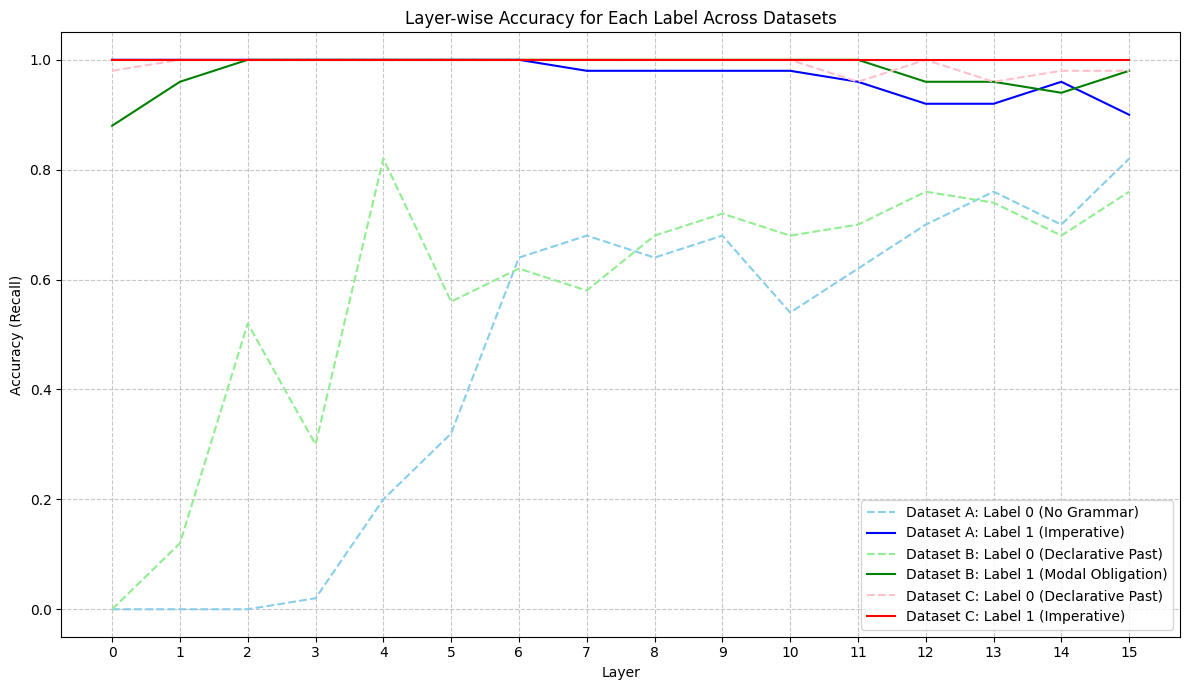

In [ ]:
layers = range(n_layers)

plt.figure(figsize=(12, 7))

# Plot Dataset A
plt.plot(layers, MLPrecall_label0_A, linestyle='--', color='skyblue', label='Dataset A: Label 0 (No Grammar)')
plt.plot(layers, MLPrecall_label1_A, linestyle='-', color='blue', label='Dataset A: Label 1 (Imperative)')

# Plot Dataset B
plt.plot(layers, MLPrecall_label0_B, linestyle='--', color='lightgreen', label='Dataset B: Label 0 (Declarative Past)')
plt.plot(layers, MLPrecall_label1_B, linestyle='-', color='green', label='Dataset B: Label 1 (Modal Obligation)')

# Plot Dataset C
plt.plot(layers, MLPrecall_label0_C, linestyle='--', color='pink', label='Dataset C: Label 0 (Declarative Past)')
plt.plot(layers, MLPrecall_label1_C, linestyle='-', color='red', label='Dataset C: Label 1 (Imperative)')

plt.xlabel('Layer')
plt.ylabel('Accuracy (Recall)')
plt.title('Layer-wise Accuracy for Each Label Across Datasets')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(-0.05, 1.05) # Set y-axis limits to clearly show 0 to 1 accuracy
plt.tight_layout()
plt.show()

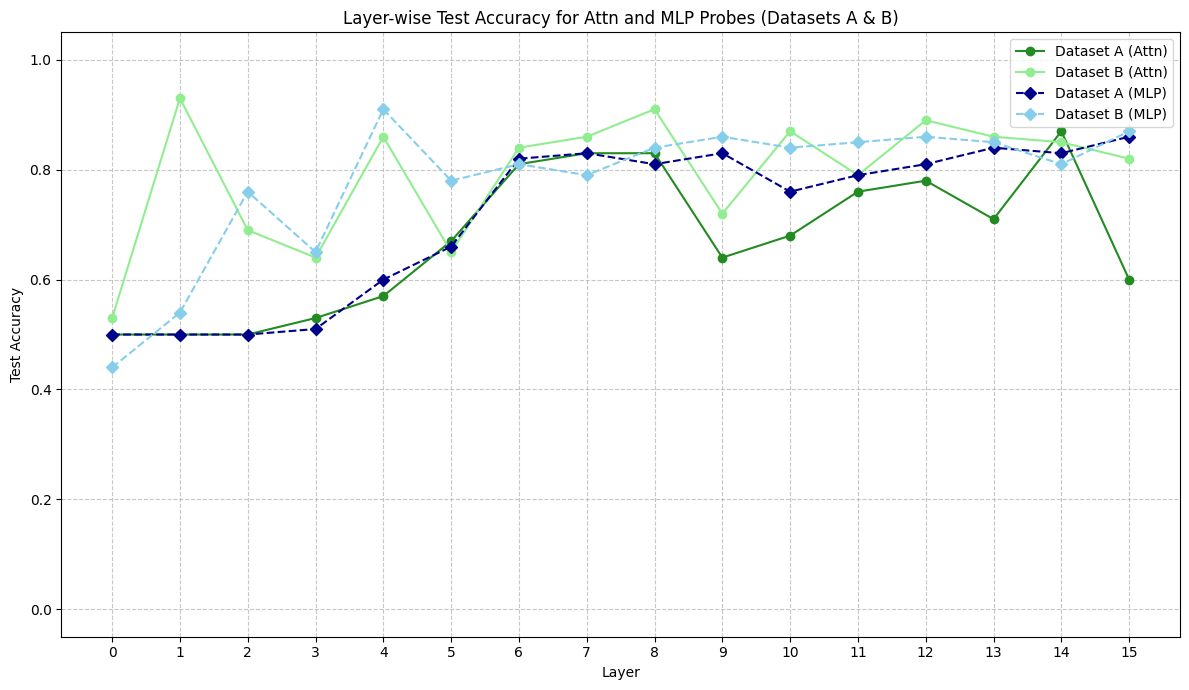

In [ ]:
import matplotlib.pyplot as plt

# Extract test accuracies for attention probes
attn_test_accs_A = [d['test_acc'] for d in layer_accs]
attn_test_accs_B = [d['test_acc'] for d in layer_accsB]

# Extract test accuracies for MLP probes
mlp_test_accs_A = [d['test_acc'] for d in MLPlayer_accs]
mlp_test_accs_B = [d['test_acc'] for d in MLPlayer_accsB]

layers = range(n_layers)

plt.figure(figsize=(12, 7))

# Plot Attention Probes
plt.plot(layers, attn_test_accs_A, linestyle='-', marker='o', color='forestgreen', label='Dataset A (Attn)')
plt.plot(layers, attn_test_accs_B, linestyle='-', marker='o', color='lightgreen', label='Dataset B (Attn)')

# Plot MLP Probes
plt.plot(layers, mlp_test_accs_A, linestyle='--', marker='D', color='darkblue', label='Dataset A (MLP)')
plt.plot(layers, mlp_test_accs_B, linestyle='--', marker='D', color='skyblue', label='Dataset B (MLP)')

plt.xlabel('Layer')
plt.ylabel('Test Accuracy')
plt.title('Layer-wise Test Accuracy for Attn and MLP Probes (Datasets A & B)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(layers)
plt.ylim(-0.05, 1.05) # Set y-axis limits to clearly show 0 to 1 accuracy
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px
from google.colab import files
import numpy as np

In [ ]:
def visualize_pca_across_layers(activation_vectors, labels, layer_idx, prefix, dataset_suffix="A"):
  """Generates and downloads 3D PCA visualizations for MLP activation vectors across all layers."""
  layer_data = activation_vectors[:, layer_idx, :]
  rule_labels = labels

  pca = PCA(n_components=3)
  pca_results = pca.fit_transform(layer_data)

  fig = px.scatter_3d(
      x=pca_results[:, 0],
      y=pca_results[:, 1],
      z=pca_results[:, 2],
      color=rule_labels,
      labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
      title=f"3D PCA Manifold of MLP Activation Vectors (Layer {layer_idx}) - Dataset A Train",
      opacity=0.8,
      color_discrete_sequence=px.colors.qualitative.Bold
  )

  fig.update_layout(
      margin=dict(l=0, r=0, b=0, t=40),
      scene=dict(
          xaxis=dict(backgroundcolor="rgba(0,0,0,0)"),
          yaxis=dict(backgroundcolor="rgba(0,0,0,0)"),
          zaxis=dict(backgroundcolor="rgba(0,0,0,0)")
      )
  )

  filename = f"{prefix}_pca_3d_layer{layer_idx}_dataset{dataset_suffix}_train.html"
  fig.write_html(filename)
  files.download(filename)


In [ ]:
# MLPs A
visualize_pca_across_layers(MLPX_train_all_A, MLPy_train_A, 4, 'MLPs_A', 'A')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_pca_across_layers(MLPX_train_all_A, MLPy_train_A, 15, 'MLPs_A', 'A')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_pca_across_layers(MLPX_train_all_B, MLPy_train_B, 4, 'MLPs_B', 'B')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_pca_across_layers(MLPX_train_all_B, MLPy_train_B, 15, 'MLPs_B', 'B')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_pca_across_layers(MLPX_train_all_C, MLPy_train_C, 4, 'MLPs_C', 'C')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
visualize_pca_across_layers(MLPX_train_all_C, MLPy_train_C, 15, 'MLPs_C', 'C')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>